Instalamos las librerias necesarias 

In [ ]:
!pip install pandas

In [2]:
import pandas as pd
datos = pd.read_csv("train.csv")

mostramos la cabesera de los datos 

In [3]:
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


aqui revisamos como y cuantos datos son los que trabajamos 

In [4]:
datos.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


empezamos a crear graficos de barra que nos muestren a los supervivientes 

<Axes: xlabel='Survived', ylabel='count'>

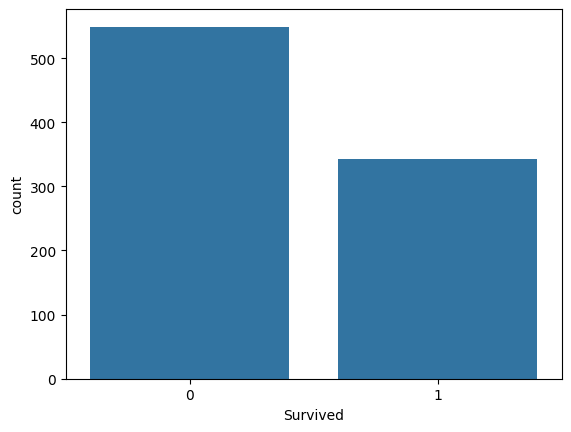

In [5]:
import seaborn as sb
sb.countplot(x="Survived", data=datos)

igual solo que muestre la cantidad de hombres y mujeres para compararar 

<Axes: xlabel='Survived', ylabel='count'>

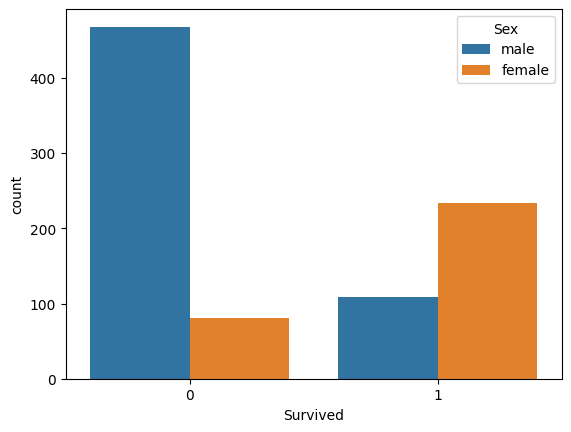

In [6]:
sb.countplot(x="Survived", hue="Sex", data=datos)

identificamos valores nulos que vienen dentro de la base de datos 

In [7]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


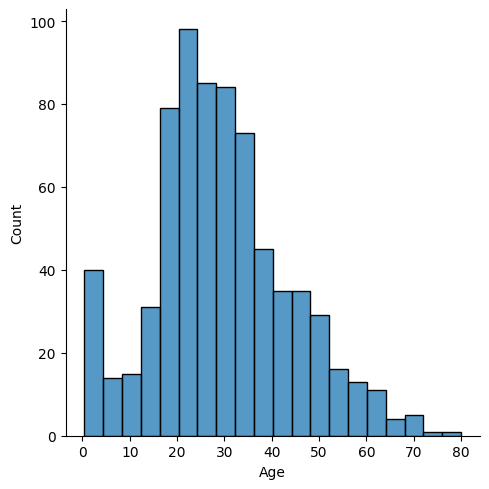

In [8]:
sb.displot(x="Age", data=datos)

mostramos los datos de las edades y en la grafica de arriba identificamos los rangos de edades de los pasajeros 

In [9]:
datos["Age"]

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


calculamos el promedio de las edades

In [10]:
datos["Age"].mean()

np.float64(29.69911764705882)

In [ ]:
mostramos las edades de los pasajeros 

In [11]:
datos["Age"].fillna(datos["Age"].mean)

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,<bound method Series.mean of 0 22.0\n1 ...
889,26.0


In [12]:
datos["Age"]

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


detectamos nuevamente valores o errores 

In [13]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


eliminamos la columna 

In [14]:
datos = datos.drop(["Cabin"], axis=1)

In [15]:
datos["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [16]:
datos = datos.dropna()

mostramos nuevamente los datos para revisar si se guardaron los cambios 

In [17]:
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


seguimos limpiando los datos 

In [18]:
datos = datos.drop(["Name", "PassengerId", "Ticket"], axis=1)

In [19]:
dummies_Sex = pd.get_dummies(datos["Sex"], drop_first=True).rename(columns={'male': 'Sex_male'})

In [20]:
datos = datos.join(dummies_Sex)
datos = datos.drop(["Sex"], axis=1)

<Axes: xlabel='Survived', ylabel='count'>

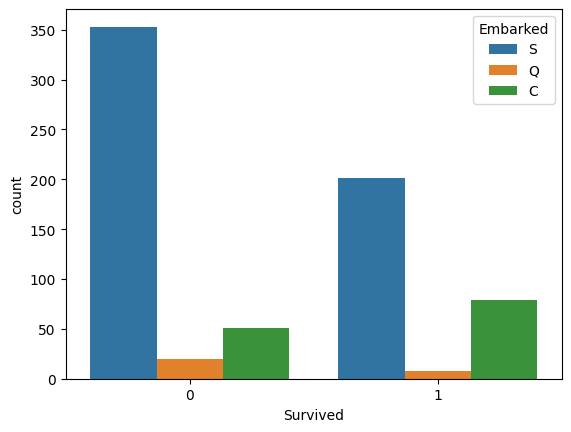

In [21]:
sb.countplot(x="Survived", hue="Embarked", data=datos)

In [22]:
dummies_embarked = pd.get_dummies(datos["Embarked"], drop_first=True)

In [24]:
datos = datos.join(dummies_embarked)
datos = datos.drop(["Embarked"], axis=1)

mostramos la correlacion de los datos en las tablas 

<Axes: >

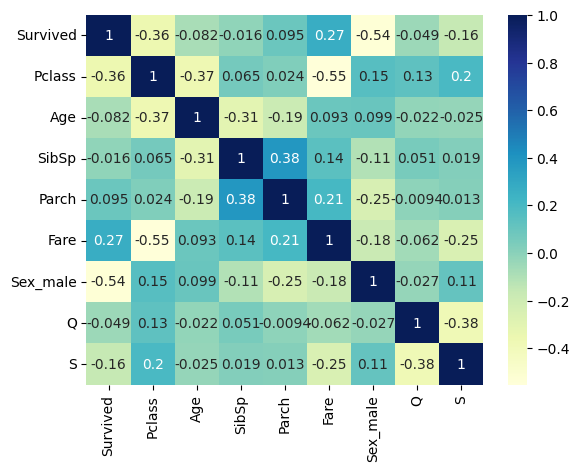

In [29]:
sb.heatmap(datos.corr(), annot=True, cmap="YlGnBu")

<Axes: xlabel='Survived', ylabel='count'>

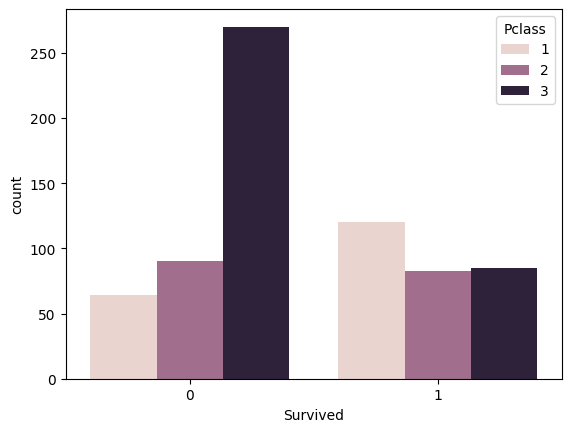

In [30]:
sb.countplot(x="Survived", data=datos, hue="Pclass")

In [35]:
X = datos.drop(["Survived"], axis=1)
y = datos["Survived"]

In [37]:
from sklearn.model_selection import train_test_split

X_ent, x_pru, y_ent, y_pru = train_test_split(X, y, test_size=0.2)

aqui estamos entrenando el modelo para que identifique los ejemplos anteriores y aprenda 

In [39]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1090)
modelo.fit(X_ent, y_ent)

LogisticRegression(max_iter=1090)

ponemos en prectica el modelo

In [40]:
predicciones = modelo.predict(x_pru)

creamos la base para que nos regrese los asiertos 

In [41]:
from sklearn.metrics import accuracy_score

accuracy_score(y_pru, predicciones)

0.7762237762237763

aqui revisamos donde falla y lo que debemos revisar del modelo

In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_pru, predicciones))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83        95
           1       0.65      0.71      0.68        48

    accuracy                           0.78       143
   macro avg       0.75      0.76      0.75       143
weighted avg       0.78      0.78      0.78       143



es una tabla que permite ver donde fallan los modelos 

In [44]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_pru, predicciones)

array([[77, 18],
       [14, 34]])

creamos una onterfas confiable que nos muestre bien los resultados 

In [48]:
pd.DataFrame(
    confusion_matrix(y_pru, predicciones),
    columns=["Prediccion No", "Prediccion Si"],
    index=["Real No", "Real Si"])


,Prediccion No,Prediccion Si
Real No,77,18
Real Si,14,34


In [49]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Q,S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


toma los datos de una persona específica (como edad, clase, etc.), los pasa por el modelo ya entrenado y te da el veredicto final según la lógica del naufragio del Titanic.

In [50]:
Nueva_persona = [3, 35, 0, 0, 10, 1, 0, 0]
prediccion = modelo.predict([Nueva_persona])
if prediccion[0] == 1:
  print("Sovreviviste")
else:
  print("No Sovreviviste")

No Sovreviviste


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
